In [1]:
import sys

sys.path.append("../../..")

import importlib, NB_config

importlib.reload(NB_config)
from NB_config import *

In [2]:
df = pd.read_csv(DATASET_PATH, low_memory=False)
cities = pd.read_csv(CITIES_META_PATH, low_memory=False)

In [3]:
print(df.columns)

Index(['business_id', 'name', 'city', 'country', 'country_name', 'continent',
       'latitude', 'longitude', 'stars', 'review_count', 'address',
       'description', 'source', 'entity_type', 'popularity', 'attr_wheelchair',
       'attr_fee', 'attr_internet_access', 'attr_smoking',
       'attr_air_conditioning', 'attr_takeaway', 'attr_capacity',
       'attr_delivery', 'attr_outdoor_seating', 'attr_diet_vegetarian',
       'attr_diet_vegan', 'has_any_attributes', 'categories_clean',
       'description_clean', 'desc_len', 'desc_score', 'cat_count', 'cat_score',
       'quality_score', 'stars_norm', 'review_count_norm', 'popularity_norm',
       'missing_description', 'missing_location', 'country_grouped_AU',
       'country_grouped_CA', 'country_grouped_DE', 'country_grouped_ES',
       'country_grouped_FR', 'country_grouped_GB', 'country_grouped_HK',
       'country_grouped_ID', 'country_grouped_IN', 'country_grouped_IT',
       'country_grouped_JP', 'country_grouped_KR', 'country_

<Axes: xlabel='stars', ylabel='Count'>

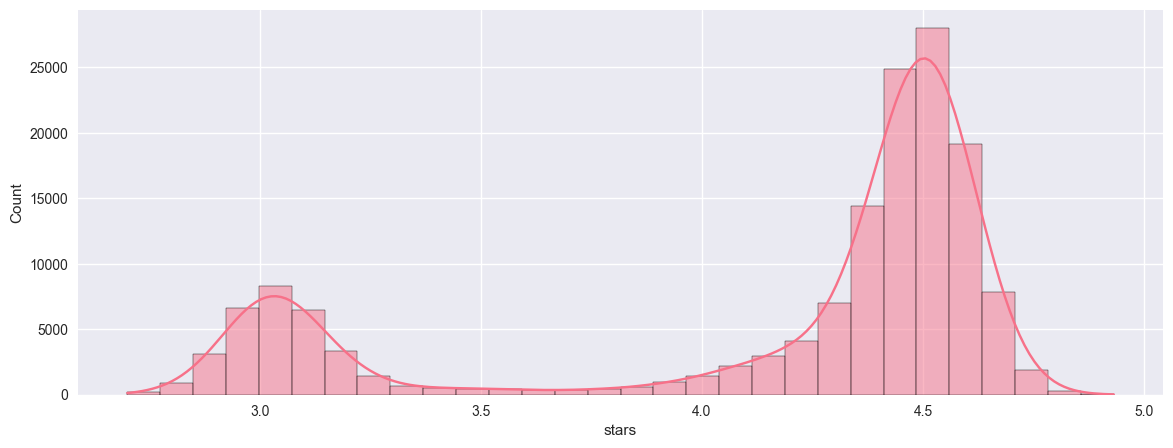

In [4]:
sns.histplot(df["stars"], bins=30, kde=True)

<Axes: xlabel='entity_type', ylabel='stars'>

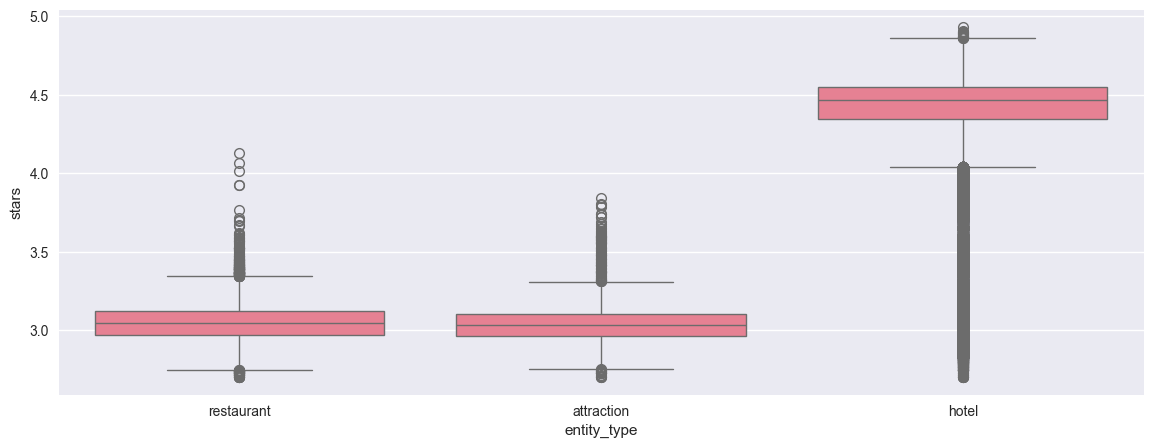

In [5]:
sns.boxplot(data=df, x="entity_type", y="stars")

In [6]:
df["popularity_score"] = df["stars"] * np.log1p(df["review_count"])

In [7]:
df.nlargest(10, "popularity_score")[["name", "stars", "review_count"]]

,name,stars,review_count
87924,Girasolereale Rome City,4.544319,72325
29868,Oxford Circus Penthouses,4.562347,67546
53622,Easy Sleep Eixample,4.622929,54799
99374,Seafield Hotel & Spa Resort,4.501753,72120
51815,Apartamentos Centro 2 El Puerto,4.612336,46948
80409,PrideInn Hotel Westlands,4.682640,35844
31370,Thistle Bloomsbury Park,4.844426,24905
61444,Ikwekwezi Guest Lodge,4.586990,43486
115479,Bellevue Berlin Hotel,4.469519,56514
124488,Newton Villa,4.527109,46701


<Axes: xlabel='review_count', ylabel='popularity'>

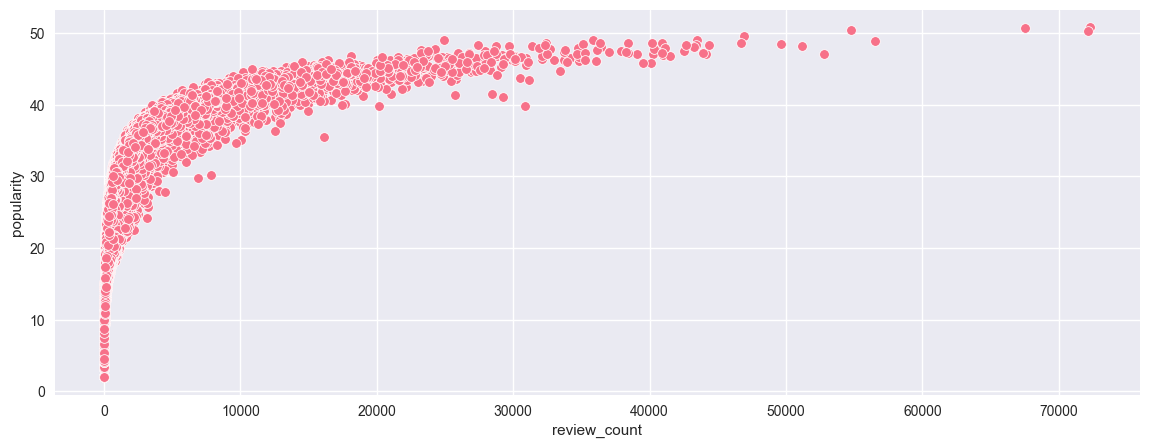

In [8]:
sns.scatterplot(data=df, x="review_count", y="popularity")

In [9]:
df[["stars", "review_count", "popularity_score"]].corr()

,stars,review_count,popularity_score
stars,1.000000,0.324838,0.878164
review_count,0.324838,1.000000,0.613929
popularity_score,0.878164,0.613929,1.000000


In [10]:
high_reviews = df[df["review_count"] > df["review_count"].quantile(0.9)]
low_reviews = df[df["review_count"] < df["review_count"].quantile(0.1)]

In [11]:
X = df[["review_count"]]
y = df["stars"]

model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


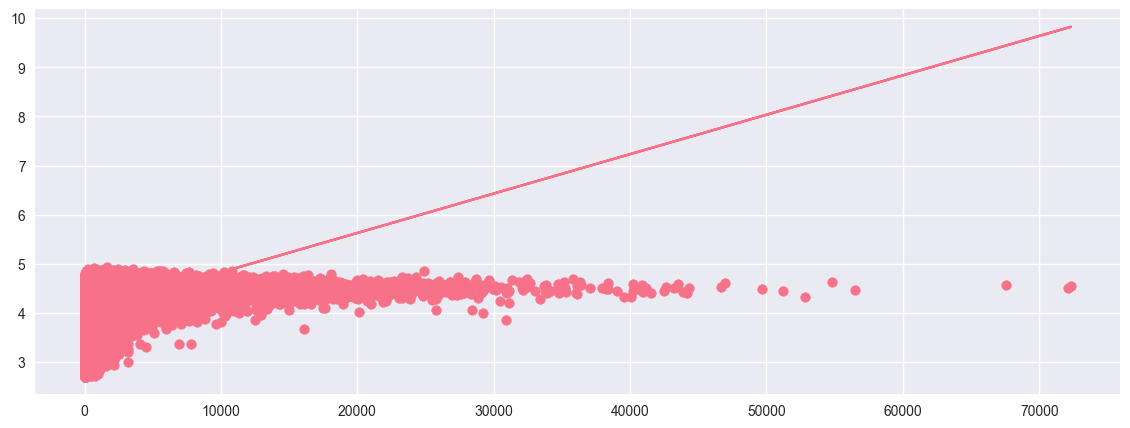

In [12]:
plt.scatter(X, y)
plt.plot(X, model.predict(X))